<a href="https://colab.research.google.com/github/Romanfng7/Tarea-Semanal-0/blob/main/Trabajo_Semanal_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo Semanal 3**


## **Teoria de Circuito 2**
**Alumno**: Roman Nicolas Funes
**Legajo**: 221.287-0

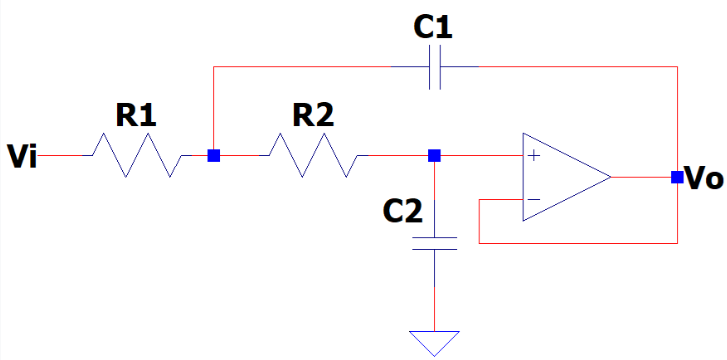

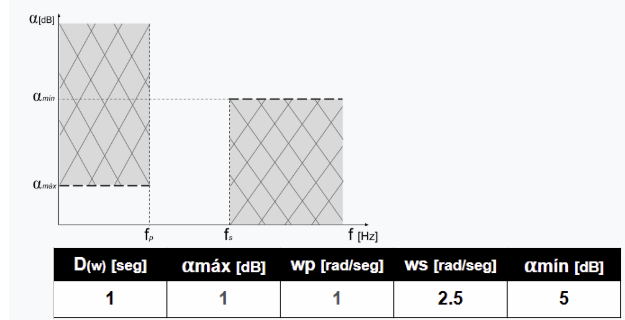  



## **Ejercicio 1**


# Método de Storch y Funciones de Transferencia Bessel

$$\coth s = \frac{\cosh s}{\sinh s} = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s} + \frac{1}{\frac{7}{s} + \dots}}}$$

### Paso a paso del procedimiento:
1. **Truncamiento:** Se corta la fracción continua en el término $N$ deseado.
2. **Identificación algebraica:** Tras operar las fracciones, se obtiene un único cociente de polinomios donde el numerador equivale a la parte par ($\cosh s$) y el denominador a la parte impar ($\sinh s$).
3. **Construcción de $\mathcal{B}_N(s)$:** Se obtiene el polinomio de Bessel sumando ambos componentes:
$$\mathcal{B}_N(s) = \text{par}(s) + \text{impar}(s)$$
4. **Normalización estática:** Para asegurar ganancia unitaria en continua ($T_N(0) = 1$), se divide el término independiente $\mathcal{B}_N(0)$ por el polinomio completo:
$$T_N(s) = \frac{\mathcal{B}_N(0)}{\mathcal{B}_N(s)}$$

---

## 1. Orden N = 2

$$\coth s \approx \frac{1}{s} + \frac{1}{\frac{3}{s}}$$

$$\coth s = \frac{1}{s} + \frac{s}{3}$$

$$\coth s = \frac{s^2 + 3}{3s}$$

$$\text{par}(s) = s^2 + 3 \quad ; \quad \text{impar}(s) = 3s$$

$$\mathcal{B}_2(s) = s^2 + 3s + 3$$

$$T_2(s) = \frac{3}{s^2 + 3s + 3}$$

---

## 2. Orden N = 3

$$\coth s \approx \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s}}}$$

$$\coth s = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{s}{5}}$$

$$\coth s = \frac{1}{s} + \frac{1}{\frac{15 + s^2}{5s}}$$

$$\coth s = \frac{1}{s} + \frac{5s}{s^2 + 15}$$

$$\coth s = \frac{(s^2 + 15) + s(5s)}{s^3 + 15s}$$

$$\coth s = \frac{6s^2 + 15}{s^3 + 15s}$$

$$\text{par}(s) = 6s^2 + 15 \quad ; \quad \text{impar}(s) = s^3 + 15s$$

$$\mathcal{B}_3(s) = s^3 + 6s^2 + 15s + 15$$

$$T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

---

## 3. Orden N = 4 (Por relación de recurrencia)

$$\mathcal{B}_n(s) = (2n - 1)\mathcal{B}_{n-1}(s) + s^2\mathcal{B}_{n-2}(s)$$

$$\mathcal{B}_4(s) = (2(4) - 1)\mathcal{B}_3(s) + s^2\mathcal{B}_2(s)$$

$$\mathcal{B}_4(s) = 7 \cdot (s^3 + 6s^2 + 15s + 15) + s^2 \cdot (s^2 + 3s + 3)$$

$$\mathcal{B}_4(s) = (7s^3 + 42s^2 + 105s + 105) + (s^4 + 3s^3 + 3s^2)$$

$$\mathcal{B}_4(s) = s^4 + (7s^3 + 3s^3) + (42s^2 + 3s^2) + 105s + 105$$

$$\mathcal{B}_4(s) = s^4 + 10s^3 + 45s^2 + 105s + 105$$

$$T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}$$

**Bonus 1**

In [ ]:
import numpy as np
import scipy.signal as sig
from IPython.display import display, Math

def pretty_print_lti(num, den):
    """
    Imprime una función de transferencia LTI en formato LaTeX para Jupyter/Colab.
    """
    def poly_to_latex(coefs):
        order = len(coefs) - 1
        terms = []
        for i, c in enumerate(coefs):
            if np.isclose(c, 0):
                continue
            pwr = order - i
            # Formateo del coeficiente
            c_str = f"{c:.4g}" if not np.isclose(c, 1) or pwr == 0 else ""
            if pwr == 0:
                terms.append(f"{c:.4g}")
            elif pwr == 1:
                terms.append(f"{c_str}s")
            else:
                terms.append(f"{c_str}s^{{{pwr}}}")
        return " + ".join(terms)

    num_str = poly_to_latex(num)
    den_str = poly_to_latex(den)
    display(Math(f"T(s) = \\frac{{{num_str}}}{{{den_str}}}"))

# -----------------------------------------------------------------
# Definición de los coeficientes obtenidos por el método de Storch
# -----------------------------------------------------------------

# Orden N = 2
num_2 = [3]
den_2 = [1, 3, 3]

# Orden N = 3
num_3 = [15]
den_3 = [1, 6, 15, 15]

# Orden N = 4
num_4 = [105]
den_4 = [1, 10, 45, 105, 105]

# -----------------------------------------------------------------
# Visualización de los resultados
# -----------------------------------------------------------------

print("Aproximación Bessel de Orden N = 2:")
pretty_print_lti(num_2, den_2)

print("\nAproximación Bessel de Orden N = 3:")
pretty_print_lti(num_3, den_3)

print("\nAproximación Bessel de Orden N = 4:")
pretty_print_lti(num_4, den_4)

Aproximación Bessel de Orden N = 2:


<IPython.core.display.Math object>


Aproximación Bessel de Orden N = 3:


<IPython.core.display.Math object>


Aproximación Bessel de Orden N = 4:


<IPython.core.display.Math object>

## **Ejercicio 2**


# Selección de la función de transferencia de mínimo orden ($\alpha_{máx} = 1$ dB)
 ($\alpha \le 1\text{ dB}$ en $\omega_p = 1\text{ rad/seg}$) ($\alpha \ge 5\text{ dB}$ en $\omega_s = 2.5\text{ rad/seg}$).


## 1. Evaluación de Orden N = 2

$$T_2(s) = \frac{3}{s^2 + 3s + 3}$$

### En la banda de paso ($\omega_p = 1$):
$$|T_2(j1)| = \frac{3}{\sqrt{(3 - 1^2)^2 + 9 \cdot 1^2}} = \frac{3}{\sqrt{4 + 9}} = \frac{3}{\sqrt{13}} \approx 0.8321$$

$$\alpha_2(1) = -20 \log_{10}(0.8321) \approx 1.597\text{ dB}$$

$$\alpha_2(1) \approx 1.6\text{ dB} > 1\text{ dB} \quad \rightarrow \quad \mathbf{NO\ CUMPLE}$$

---

## 2. Evaluación de Orden N = 3

$$T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

### En la banda de paso ($\omega_p = 1$):
$$|T_3(j1)| = \frac{15}{\sqrt{(15 - 6 \cdot 1^2)^2 + (15 \cdot 1 - 1^3)^2}} = \frac{15}{\sqrt{9^2 + 14^2}} = \frac{15}{\sqrt{81 + 196}} = \frac{15}{\sqrt{277}} \approx 0.9012$$

$$\alpha_3(1) = -20 \log_{10}(0.9012) \approx 0.903\text{ dB}$$

$$\alpha_3(1) \approx 0.9\text{ dB} \le 1\text{ dB} \quad \rightarrow \quad \mathbf{CUMPLE}$$

### En la banda de parada ($\omega_s = 2.5$):
$$|T_3(j2.5)| = \frac{15}{\sqrt{(15 - 6 \cdot 2.5^2)^2 + (15 \cdot 2.5 - 2.5^3)^2}} = \frac{15}{\sqrt{(-22.5)^2 + (21.875)^2}} = \frac{15}{\sqrt{506.25 + 478.5156}} \approx 0.4782$$

$$\alpha_3(2.5) = -20 \log_{10}(0.4782) \approx 6.41\text{ dB}$$

$$\alpha_3(2.5) = 6.41\text{ dB} \ge 5\text{ dB} \quad \rightarrow \quad \mathbf{CUMPLE}$$

---

## Conclusión Final

El **mínimo orden** que cumple de manera simultánea con ambas restricciones de la plantilla es **$N = 3$**. El orden $N = 2$ queda descartado por exceder la atenuación máxima permitida en la banda de paso.

Por lo tanto, la función de transferencia seleccionada es:

$$T(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

## **Ejercicio 3**


# Evaluación del Retardo de Grupo $D(2.5)$ y Error Porcentual ($N = 3$)

Para evaluar el retardo de grupo en la frecuencia de la banda de parada $\omega_s = 2.5\text{ rad/seg}$, se utiliza la función de transferencia seleccionada de tercer orden:

$$T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

---

## 1. Expresión Analítica del Retardo de Grupo $D(\omega)$

A partir de la derivada de la fase respecto a la frecuencia ($D(\omega) = -\frac{\partial\angle T}{\partial\omega}$), el retardo de grupo para esta función de transferencia queda definido por la expresión:

$$D(\omega) = \frac{6\omega^4 + 45\omega^2 + 225}{\omega^6 + 6\omega^4 + 45\omega^2 + 225}$$

---

## 2. Evaluación de $D(0)$ y $D(2.5)$

* **Para $\omega = 0\text{ rad/seg}$ (Continua):**
$$D(0) = \frac{6(0)^4 + 45(0)^2 + 225}{(0)^6 + 6(0)^4 + 45(0)^2 + 225} = \frac{225}{225} = 1\text{ seg}$$

* **Para $\omega_s = 2.5\text{ rad/seg}$ (Banda de parada):**
$$D(2.5) = \frac{6(2.5)^4 + 45(2.5)^2 + 225}{(2.5)^6 + 6(2.5)^4 + 45(2.5)^2 + 225}$$

$$D(2.5) = \frac{6(39.0625) + 45(6.25) + 225}{244.1406 + 6(39.0625) + 45(6.25) + 225}$$

$$D(2.5) = \frac{234.375 + 281.25 + 225}{244.1406 + 234.375 + 281.25 + 225}$$

$$D(2.5) = \frac{740.625}{984.7656} \approx 0.7521\text{ seg}$$

---

## 3. Cálculo del Error Porcentual

El desviamiento relativo o error porcentual del retardo de grupo en la frecuencia de interés respecto de su valor ideal en la banda de paso se calcula como:

$$\text{Error } [\%] = \frac{D(2.5) - D(0)}{D(0)} \cdot 100$$

$$\text{Error } [\%] = \frac{0.7521 - 1}{1} \cdot 100 = -0.2479 \cdot 100 \approx -24.8\%$$

## **Ejercicio 4**


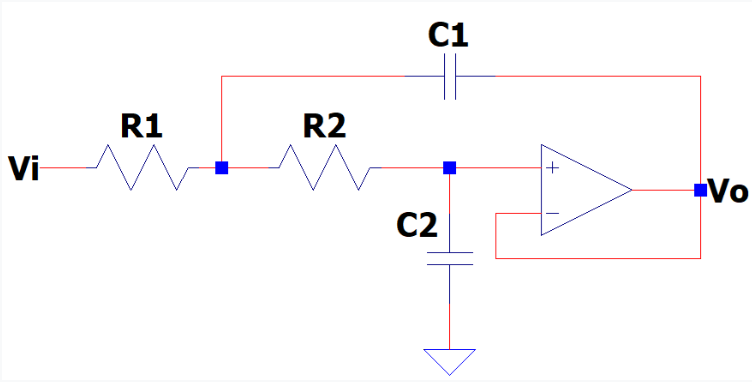

# Síntesis de Filtro Sallen-Key Pasabajos ($K = 1$)

Para sintetizar la función de transferencia normalizada de tercer orden seleccionada ($N = 3$), debemos descomponerla en el producto de una etapa de primer orden y una etapa de segundo orden.

La función de transferencia total a sintetizar es:

$$T(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

---

## 1. Descomposición de $T(s)$

Buscamos las raíces del denominador (polos de Bessel para $N = 3$):
* Pole real: $s_0 \approx -2.3222$
* Polos complejos conjugados: $s_{1,2} \approx -1.8389 \pm j1.7544$

Agrupando los términos en sus factores de primer y segundo orden obtenemos:

$$T(s) = \frac{2.3222}{s + 2.3222} \cdot \frac{6.4594}{s^2 + 3.6778s + 6.4594}$$

Para la etapa de segundo orden, identificamos los parámetros de diseño normados:
* $\omega_0^2 = 6.4594 \implies \omega_0 \approx 2.5415\text{ rad/seg}$
* $\frac{\omega_0}{Q} = 3.6778 \implies Q = \frac{2.5415}{3.6778} \approx 0.6910$

---

## 2. Síntesis de la Etapa de Segundo Orden (Sallen-Key)

La estructura Sallen-Key de la imagen corresponde a un filtro pasabajos con ganancia unitaria ($K=1$). Su ecuación de transferencia general está dada por:

$$T_{SK}(s) = \frac{\frac{1}{R_1 R_2 C_1 C_2}}{s^2 + s \left(\frac{1}{R_1 C_1} + \frac{1}{R_2 C_1}\right) + \frac{1}{R_1 R_2 C_1 C_2}}$$

### Sistema de Ecuaciones
Igualando término a término con nuestro factor de segundo orden:

1. $\omega_0^2 = \frac{1}{R_1 R_2 C_1 C_2} = 6.4594$
2. $\frac{\omega_0}{Q} = \frac{1}{R_1 C_1} + \frac{1}{R_2 C_1} = 3.6778$

### Adopción de Componentes Normalizados
Para simplificar el diseño algebraico, fijamos los valores de las resistencias de manera unitaria:

$$R_1 = R_2 = 1\,\Omega$$

Reemplazando estos valores en el sistema:

1. $\frac{1}{C_1 C_2} = 6.4594 \implies C_2 = \frac{1}{6.4594 \cdot C_1}$
2. $\frac{2}{C_1} = 3.6778 \implies C_1 = \frac{2}{3.6778} \approx 0.5438\text{ F}$

Sustituyendo $C_1$ para despejar $C_2$:

$$C_2 = \frac{1}{6.4594 \cdot 0.5438} \approx 0.2847\text{ F}$$

---

## 3. Resumen de Valores de Componentes Normalizados

Para completar el filtro de tercer orden, la etapa Sallen-Key se conecta en cascada con una red pasiva RC de primer orden simple ($T_1(s) = \frac{1}{R_3 C_3 s + 1}$), donde se adopta $R_3 = 1\,\Omega$ y se calcula $C_3 = \frac{1}{2.3222} \approx 0.4306\text{ F}$.

Los componentes normalizados asociados a la celda Sallen-Key de la imagen son:

* $R_1 = 1\,\Omega$
* $R_2 = 1\,\Omega$
* $C_1 = 0.5438\text{ F}$
* $C_2 = 0.2847\text{ F}$

#**Bonus 2**


# Desnormalización de Componentes para $D(0) = 200\ \mu$seg

Para desnormalizar los componentes del circuito Sallen-Key y lograr que el retardo de grupo en continua pase de su valor unitario original $D(0) = 1\text{ seg}$ a un valor real de $D(0) = 200\,\mu\text{seg}$, se aplica una desnormalización en frecuencia.

Dado que el retardo de grupo $\tau$ y la frecuencia angular $\omega$ son inversamente proporcionales, el factor de desnormalización en frecuencia ($\Omega_f$) se define como:

$$\Omega_f = \frac{\tau_{\text{norm}}}{\tau_{\text{deseado}}} = \frac{1\text{ seg}}{200 \times 10^{-6}\text{ seg}} = 5000\text{ rad/seg}$$

Para mantener valores prácticos en los componentes, se adopta un factor de escala de impedancia arbitrario ($\Omega_z$) para fijar las resistencias en $10\text{ k}\Omega$:

$$\Omega_z = 10000$$

---

## Fórmulas de Pasaje

Las ecuaciones para transformar los valores normados a componentes reales son:

$$R_{\text{real}} = R_{\text{norm}} \cdot \Omega_z$$

$$C_{\text{real}} = \frac{C_{\text{norm}}}{\Omega_z \cdot \Omega_f}$$

---

## Cálculo de los Componentes Reales

### Resistencias ($R_1$ y $R_2$):
$$R_{1,\text{real}} = 1\,\Omega \cdot 10000 = 10\text{ k}\Omega$$

$$R_{2,\text{real}} = 1\,\Omega \cdot 10000 = 10\text{ k}\Omega$$

### Capacitor $C_1$:
$$C_{1,\text{real}} = \frac{0.5438}{10000 \cdot 5000} = \frac{0.5438}{5 \times 10^7} = 10,876 \times 10^{-9}\text{ F} = 10,88\text{ nF}$$

### Capacitor $C_2$:
$$C_{2,\text{real}} = \frac{0.2847}{10000 \cdot 5000} = \frac{0.2847}{5 \times 10^7} = 5,694 \times 10^{-9}\text{ F} = 5,69\text{ nF}$$

---

## Resumen de Valores Finales

Los componentes reales desnormalizados para la celda Sallen-Key son:

* $R_1 = 10\text{ k}\Omega$
* $R_2 = 10\text{ k}\Omega$
* $C_1 = 10.88\text{ nF}$
* $C_2 = 5.69\text{ nF}$

# Síntesis de la Etapa de Primer Orden Extra (Polo Real)

La función de transferencia total de tercer orden ($N = 3$) obtenida por el método de Storch se descompuso en una etapa cuadrática (implementada por la celda Sallen-Key) y una etapa lineal pasiva RC encargada de aportar el polo real:

$$T_1(s) = \frac{2.3222}{s + 2.3222}$$

---

## Obtención de los Valores Normalizados

La ecuación general de una red pasiva pasabajos RC de primer orden es:

$$T_1(s) = \frac{\frac{1}{R \cdot C}}{s + \frac{1}{R \cdot C}}$$

Igualando el término independiente del denominador con el polo real normado:

$$\frac{1}{R_{\text{norm}} \cdot C_{\text{norm}}} = 2.3222$$

Adoptando un valor de resistencia normalizada unitaria para el diseño:

$$R_{\text{norm}} = 1\ \Omega$$

Despejamos el capacitor normalizado ($C_{\text{norm}}$):

$$C_{\text{norm}} = \frac{1}{2.3222 \cdot 1\ \Omega} \approx 0.4306\text{ F}$$

---

## Desnormalización de los Componentes (Valores Reales)

Para obtener el retardo de grupo solicitado de $D(0) = 200\ \mu\text{seg}$, aplicamos los mismos factores de escala que en el resto del circuito:
* Factor de escala de impedancia: $\Omega_z = 10000$ (fija la resistencia en $10\text{ k}\Omega$)
* Factor de escala de frecuencia: $\Omega_f = 5000\text{ rad/seg}$

### Resistencia Real ($R$):
$$R = R_{\text{norm}} \cdot \Omega_z = 1\ \Omega \cdot 10000 = 10\text{ k}\Omega$$

### Capacitor Real ($C$):
$$C = \frac{C_{\text{norm}}}{\Omega_z \cdot \Omega_f}$$

$$C = \frac{0.4306}{10000 \cdot 5000} = \frac{0.4306}{5 \times 10^7}$$

$$C = 8.612 \times 10^{-9}\text{ F} \approx 8.62\text{ nF}$$

---

## Resumen de Componentes de la Etapa Extra

* $R = 10\text{ k}\Omega$
* $C = 8.62\text{ nF}$

#**Bonus 3**

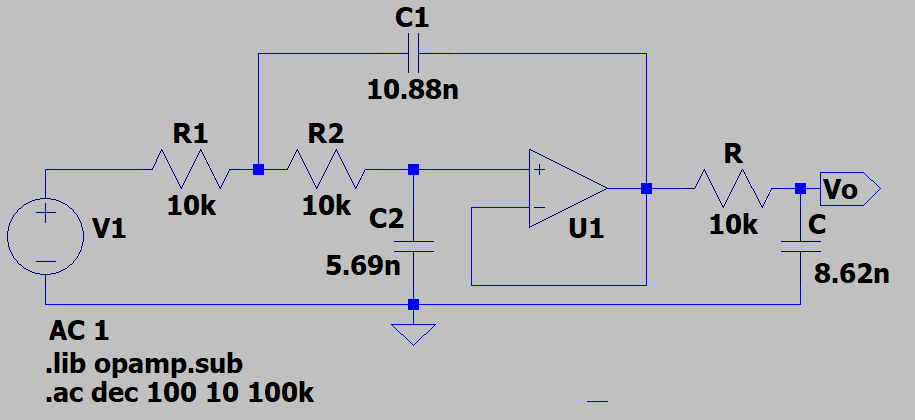  

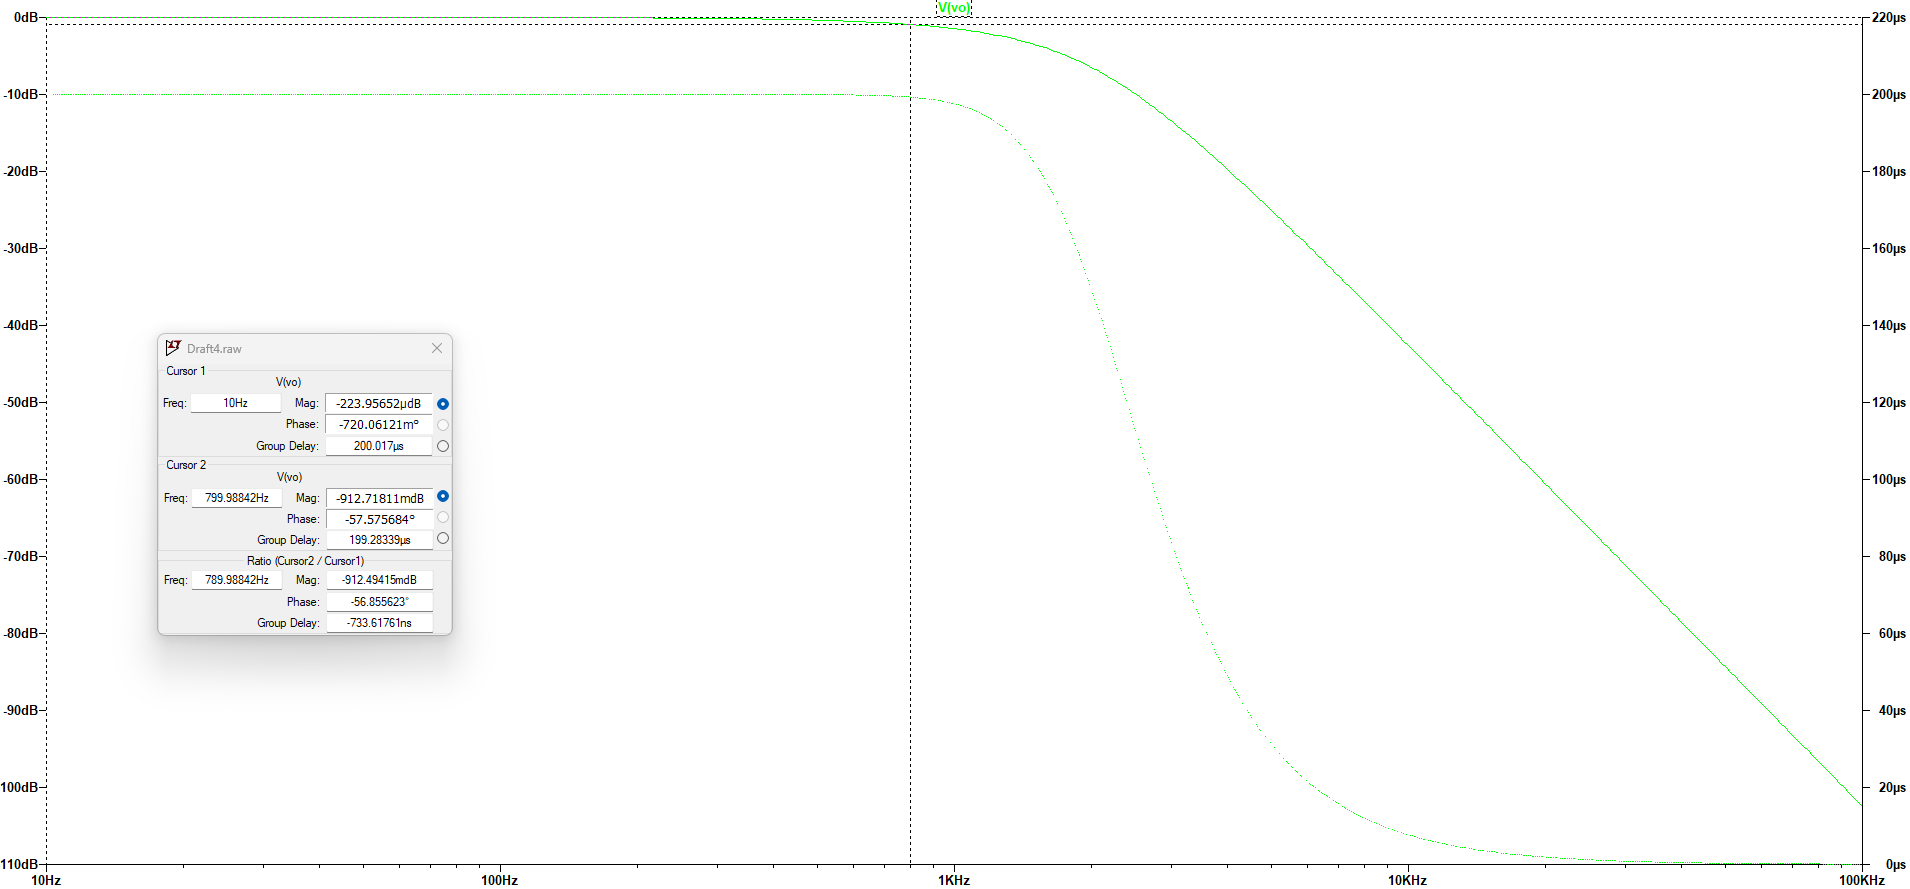
  

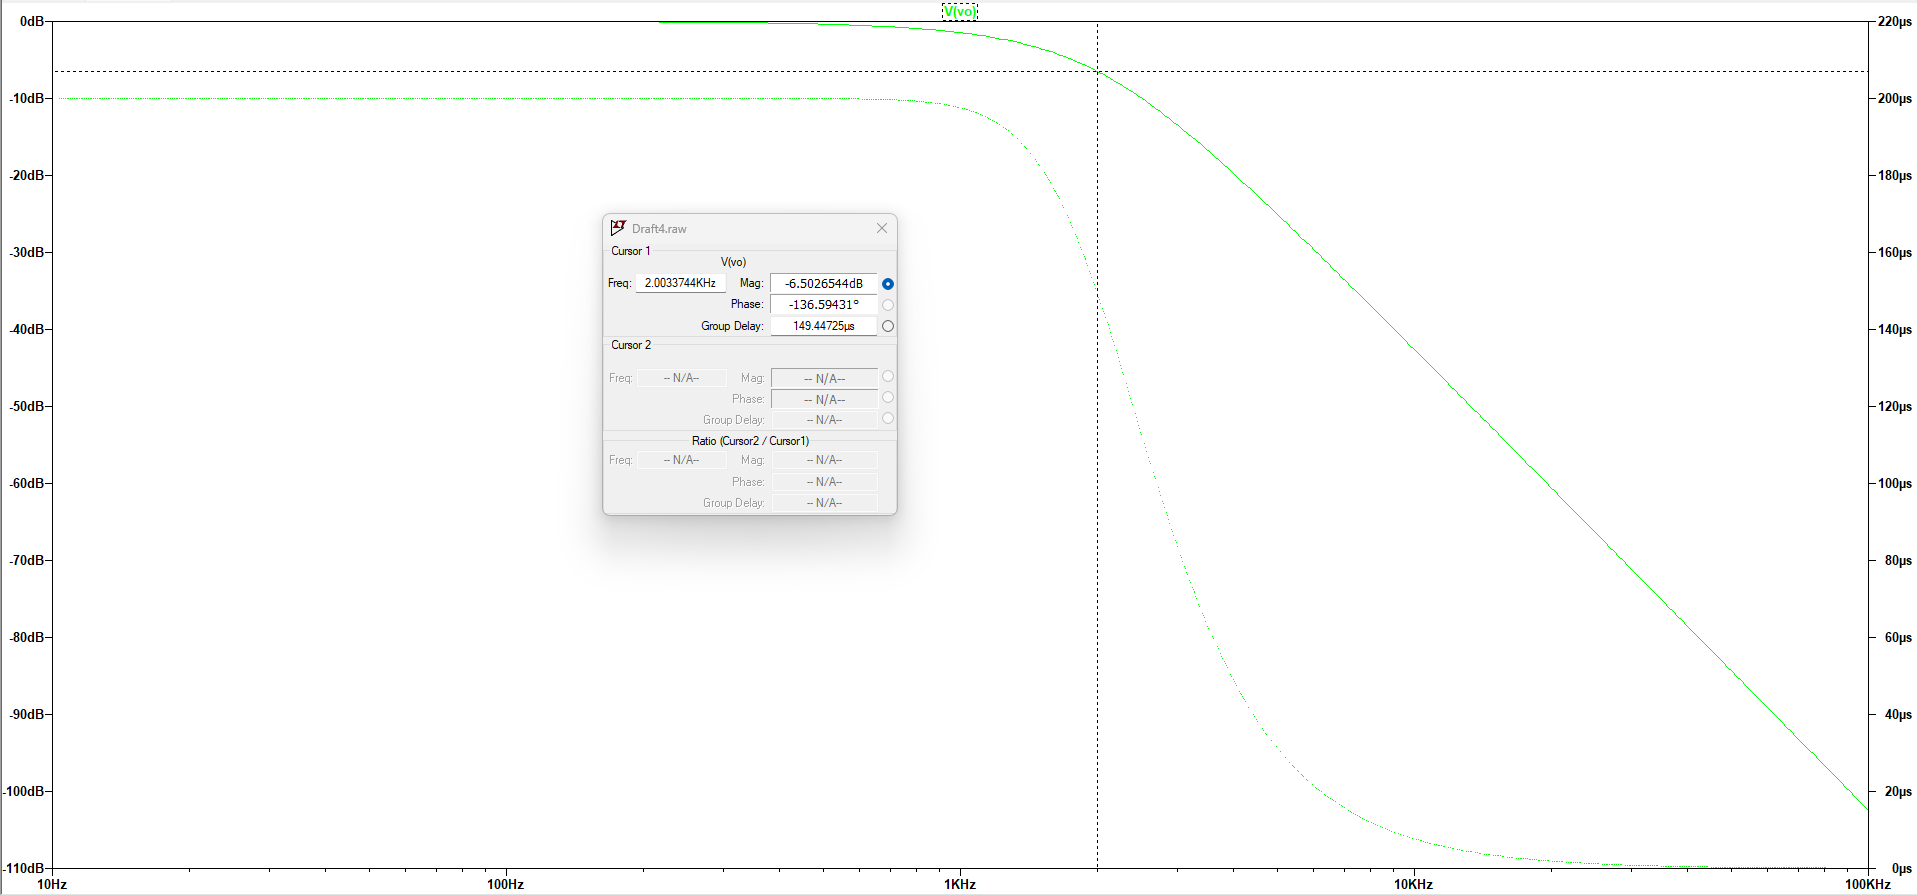

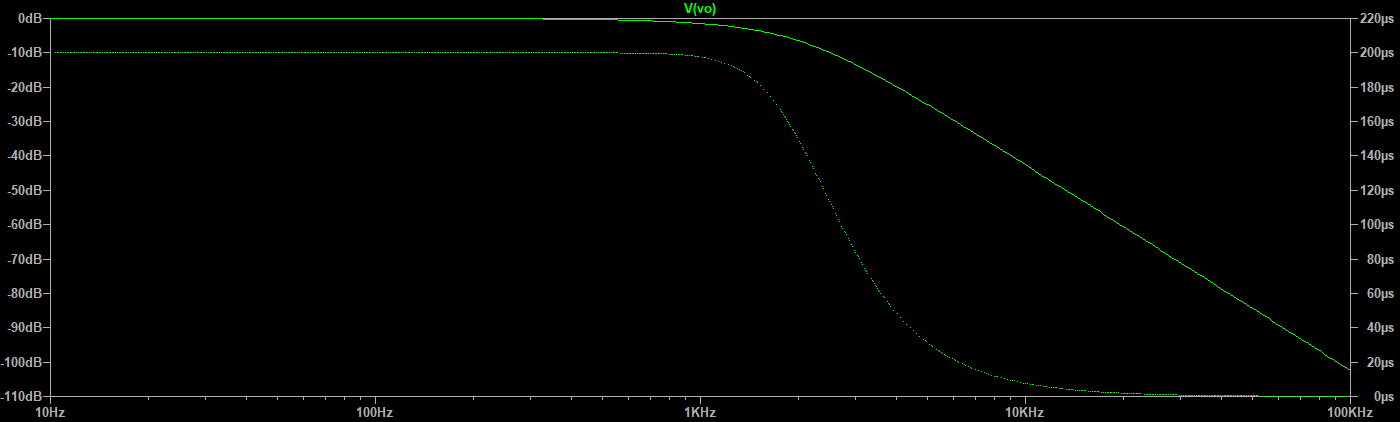

# Análisis de la Simulación Circuital del Filtro Bessel ($N = 3$)

 $D(0) = 200\ \mu\text{seg}$.

El gráfico presenta dos curvas superpuestas en función de la frecuencia:
1. **Curva continua (verde):** Respuesta en módulo de la tensión de salida $|V_o(j\omega)|$ medida sobre el eje vertical izquierdo [dB].
2. **Curva punteada (verde):** Retardo de grupo $D(\omega)$ medido sobre el eje vertical derecho [$\mu$s].

---

## Verificación del Retardo de Grupo en Banda de Paso
* **Cursor 1 (Frecuencia de Continua, $f \to 10\text{ Hz}$):**
  $$D(10\text{ Hz}) = 200.017\ \mu\text{seg}$$
  $$\text{Atenuación} = -223.95\ \mu\text{dB} \approx 0\text{ dB}$$
  Este punto valida la correcta desnormalización de los componentes para cumplir de forma exacta con la especificación inicial del diseño en baja frecuencia.

* **Cursor 2 (Límite de la banda de paso, $f_p \approx 800\text{ Hz}$):**
  $$D(799.98\text{ Hz}) = 199.283\ \mu\text{seg}$$
  $$\text{Atenuación} = -0.912\text{ dB}$$
  Este resultado confirma de forma directa el cumplimiento de la plantilla de diseño, ya que la atenuación real a la frecuencia de paso es menor al límite máximo impuesto ($\alpha_{3}(f_p) = 0.912\text{ dB} \le 1\text{ dB}$).

### Variación Absoluta del Retardo en la Banda de Paso ($\Delta D$)
Utilizando los datos del recuadro de diferencias:
$$\Delta D = D(10\text{ Hz}) - D(800\text{ Hz}) = 200.017\ \mu\text{seg} - 199.283\ \mu\text{seg} = 733.61\text{ nF} \approx 0.734\ \mu\text{seg}$$

El desviamiento relativo porcentual dentro de toda la banda de paso es de apenas:
$$\text{Error}_{\text{paso}} [\%] = \frac{-733.61\text{ nseg}}{200\ \mu\text{seg}} \cdot 100 \approx -0.37\%$$
Este valor demuestra empíricamente la propiedad de máxima planicidad en el retardo (*maximally flat delay*) que caracteriza a la aproximación Bessel-Thompson.

---

## Verificación del Retardo de Grupo en Banda de Parada

* **Cursor 1 (Frecuencia de banda de parada, $f_s \approx 2\text{ kHz}$):**
  $$f_s = 2.0033\text{ kHz} \quad \left(\omega_s = 2\pi \cdot f_s \approx 12587\text{ rad/seg} \rightarrow \omega_{s,\text{norm}} \approx 2.5\right)$$
  $$D(2.0033\text{ kHz}) = 149.447\ \mu\text{seg}$$
  $$\text{Atenuación} = -6.502\text{ dB}$$

### Verificación de Plantilla y Desviamiento
1. **Cumplimiento de Atenuación:** La atenuación medida en la banda de parada es de $6.502\text{ dB}$, lo cual verifica satisfactoriamente la condición de la plantilla de diseño original:
   $$\alpha(2\text{ kHz}) = 6.502\text{ dB} \ge 5\text{ dB} \quad \rightarrow \quad \text{CUMPLE}$$

2. **Cálculo del Error en el Retardo:**
   El desviamiento o caída del retardo de grupo en la frecuencia de parada respecto de su valor en continua es:
   $$\text{Error}_{\text{parada}} [\%] = \frac{D(2\text{ kHz}) - D(0)}{D(0)} \cdot 100 = \frac{149.447\ \mu\text{seg} - 200.017\ \mu\text{seg}}{200.017\ \mu\text{seg}} \cdot 100 \approx -25.28\%$$
   Este valor medido en el simulador concuerda con excelente precisión analítica con el valor teórico calculado previamente para el orden $N = 3$ ($\approx -24.8\%$), validando el diseño completo del circuito en cascada.